# Notebook overview

This notebook loads processed hourly mean AQUM gridded fields and AURN-site-extracted values, then rasterizes (maps) AURN site ozone observations back onto the AQUM model grid using nearest-neighbour assignment. For each hourly time step, it saves the rasterized ozone field together with corresponding meteorological variables (temperature, pressure, relative humidity, wind components) and gridded ozone as separate NetCDF files—enabling structured training data generation for downstream machine-learning pipelines.

# Imports

In [1]:
#import matplotlib.pyplot as plt
import warnings
# turn off futurewarning from iris
warnings.filterwarnings("ignore", category=FutureWarning)
# turn off netcdf unknown variable warning from iris
warnings.filterwarnings("ignore", category=UserWarning, message=".*NetCDF variable.*")
# turn off IrisCfNonSpanningVarWarning
warnings.filterwarnings("ignore", category=UserWarning, message=".*IrisCfNonSpanningVarWarning.*")

import numpy as np

from matplotlib import pyplot as plt

import iris
from iris.analysis.cartography import unrotate_pole
iris.FUTURE.save_split_attrs = True
# iris.FUTURE.datum_support = False

/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# Main

## Read hourly means from netcdf

In [2]:
# filter by site_type to get only rural sites 
site_constraint = iris.Constraint(site_type=['RURAL_BACKGROUND'])
site_constraint = iris.Constraint(site_type=['RURAL_BACKGROUND', 'URBAN_BACKGROUND','SUBURBAN_BACKGROUND'])

# load the hourly means from post processed files
model_datadir = 'processed_data/'
gridded_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_gridded_cube_list_hourly_means.nc')
site_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_sites_cube_list_hourly_means.nc', site_constraint)

print(f"\nGridded cube list after loading hourly means:")
print(gridded_cube_list_hourly)
print(f"\nSite cube list after loading hourly means:")
print(site_cube_list_hourly)

print("\nChecking short_name attributes in gridded cube list:")
for cube in gridded_cube_list_hourly:
    if 'short_name' in cube.attributes:
        print(f" ... short_name: {cube.attributes['short_name']}")

# extracting specific fields from the gridded cube list and site cube list using short_name constraints 
Ozone_constraint = iris.AttributeConstraint(short_name='O3')
ozone_gridded = gridded_cube_list_hourly.extract_cube(Ozone_constraint)

t_1p5_constraint = iris.AttributeConstraint(short_name='T_1p5')
t_1p5_gridded = gridded_cube_list_hourly.extract_cube(t_1p5_constraint)

p_msl_constraint = iris.AttributeConstraint(short_name='p_msl')
p_msl_gridded = gridded_cube_list_hourly.extract_cube(p_msl_constraint)

rh_1p5_constraint = iris.AttributeConstraint(short_name='rh_1p5')
rh_1p5_gridded = gridded_cube_list_hourly.extract_cube(rh_1p5_constraint)

u_10m_constraint = iris.AttributeConstraint(short_name='u_10m')
u_10m_gridded = gridded_cube_list_hourly.extract_cube(u_10m_constraint)

v_10m_constraint = iris.AttributeConstraint(short_name='v_10m')
v_10m_gridded = gridded_cube_list_hourly.extract_cube(v_10m_constraint)

jNO2_constraint = iris.AttributeConstraint(short_name='jNO2')
jNO2_gridded = gridded_cube_list_hourly.extract_cube(jNO2_constraint)

precip_constraint = iris.AttributeConstraint(short_name='total_precip')
precip_gridded = gridded_cube_list_hourly.extract_cube(precip_constraint)

# ozone at sites
ozone_sites = site_cube_list_hourly.extract_cube(Ozone_constraint)


Gridded cube list after loading hourly means:
0: daily_air_quality_index_of_ozone / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
1: daily_air_quality_index_of_sulfur_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
2: daily_air_quality_index / (1)       (time: 93; grid_latitude: 112; grid_longitude: 88)
3: daily_air_quality_index_of_nitrogen_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
4: daily_air_quality_index_of_nitrogen_monoxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
5: air_pressure_at_sea_level / (Pa)    (time: 2209; grid_latitude: 112; grid_longitude: 88)
6: air_temperature / (K)               (time: 2209; grid_latitude: 112; grid_longitude: 88)
7: mass_concentration_of_ammonia_in_air / (ug/m3) (time: 737; grid_latitude: 112; grid_longitude: 88)
8: mass_concentration_of_nitrogen_dioxide_in_air / (ug/m3) (time: 2209; grid_latitude: 112; grid_longitude: 88)
9: mass_concentration_of_nitrogen_monoxide_in_air / (ug/m3) (

## Loop over time

In [3]:
# extract dimension of arrays
ntime = ozone_gridded.coord('time').points.size
nlat = ozone_gridded.coord('grid_latitude').points.size
nlon = ozone_gridded.coord('grid_longitude').points.size
print(f"Ozone gridded cube dimensions: time={ntime}, lat={nlat},  lon={nlon}")

nsites = ozone_sites.coord('site_id').points.size
print(f"Ozone sites cube dimensions: time={ntime}, sites={nsites}")

# initialise a cube list to hold the rasterized ozone values at the AURN sites
rasterized_ozone_at_aurn_site = np.empty((ntime, nlat, nlon))

# initialize lists to store site lat/lon, rotated lat/lon and ozone values
sites_lat = np.empty((ntime, nsites))
sites_lon = np.empty((ntime, nsites))
sites_rotated_lat = np.empty((ntime, nsites))
sites_rotated_lon = np.empty((ntime, nsites))
sites_ozone = np.empty((ntime, nsites))
date_str = []

# set the number of time steps to process (for testing, set to 1 or 2, for full processing set to ntime)
# nstart = 0     # set to 0 to start from the beginning, or set to a specific time step index to start from there
nstart = 1439   # set to 1750 to start from the middle of the time series, or set to a specific time step index to start from there

nstop = ntime   # set to ntime to process all time steps, or set to a specific time step index to stop before that
nstop = 1800 # set to 1750 to stop after processing 1750 time steps, or set to a specific time step index to stop before that

for nt, (ozone_gridded_time_slice, 
         t_1p5_gridded_time_slice,
         rh_1p5_gridded_time_slice,
         p_msl_gridded_time_slice,
         u_10m_gridded_time_slice,
         v_10m_gridded_time_slice,
         ozone_at_site_time_slice,
         jNO2_gridded_time_slice,
         precip_gridded_time_slice) in enumerate(zip(
            ozone_gridded.slices_over('time'),
            t_1p5_gridded.slices_over('time'),
            rh_1p5_gridded.slices_over('time'),
            p_msl_gridded.slices_over('time'),
            u_10m_gridded.slices_over('time'),
            v_10m_gridded.slices_over('time'),
            ozone_sites.slices_over('time'),
            jNO2_gridded.slices_over('time'),
            precip_gridded.slices_over('time')
            )):

    # print(ozone_gridded_time_slice)
    # print(p_msl_gridded_time_slice)
    # print("\n\n")

    # end loop after nstop iteration
    if nt >= nstop:
        break

    # extract the time coordinate and convert to datetime for printing
    time_coord = ozone_gridded_time_slice.coord('time')
    dt = time_coord.units.num2date(time_coord.points)       # returns an array-like of datetimes
    date_str.append(dt[0].strftime("%Y-%m-%d %H:%M:%S"))          # format as you like

    # skip time steps before nstart (but keep date_str populated so date_str[nt] remains valid)
    if nt < nstart:
        print(f'{nt} - Skipping time step for date: {date_str[nt]}')
        continue
    else:
        print(f'{nt} - Processing cubes for date: {date_str[nt]}')

    ozone_field = ozone_gridded_time_slice.copy()
    ozone_field.data = np.full_like(ozone_gridded_time_slice.data, np.nan)
    rasterized_ozone_at_aurn_site[nt, :, :] = ozone_field.data

    # Define the unrotated grid for AQUM (initialised on the first processed time step)
    if nt == nstart:
        # Rotated pole properties
        pole_lon = ozone_gridded_time_slice.coord('grid_longitude').coord_system.grid_north_pole_longitude
        pole_lat = ozone_gridded_time_slice.coord('grid_latitude').coord_system.grid_north_pole_latitude
        lat_grid = ozone_gridded_time_slice.coord('grid_latitude').points
        lon_grid = ozone_gridded_time_slice.coord('grid_longitude').points - 360.0
        # print(f"\nTarget lat grid: {lat_grid}")
        # print(f"\nTarget lon grid: {lon_grid}")
        lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
        lon2d_unrotated, lat2d_unrotated = unrotate_pole(lon2d, lat2d, pole_lon, pole_lat)


    # unpack the ozone at sites values and coords
    for ns, site in enumerate(ozone_at_site_time_slice.slices_over('site_id')):

        # Read sites values, lat/lon and rotated lat/lon from the cube coordinates
        # site_id = site.coord('site_id').points[0]
        site_lat = site.coord('latitude').points[0]
        site_lon = site.coord('longitude').points[0]
        site_rotated_lat = site.coord('grid_latitude').points[0]
        site_rotated_lon = site.coord('grid_longitude').points[0]

        # print(f"Site ID: {site_id}")
        # print(f"Site lat: {site_lat}, Site lon: {site_lon}")
        # print(f"Site rotated lat: {site_rotated_lat}, Site rotated lon: {site_rotated_lon}")

        # Append the values to the arrays
        sites_ozone[nt, ns] = site.data
        sites_lat[nt, ns] = site_lat
        sites_lon[nt, ns] = site_lon
        sites_rotated_lat[nt, ns] = site_rotated_lat
        sites_rotated_lon[nt, ns] = site_rotated_lon

    # Find nearest indices to the model lat/lon grid points for each site and create a unique id
    unique_ids = []
    for ns in range(nsites):
        # find the nearest grid point to the site rotated lat/lon
        nearest_lat_idx = np.argmin(np.abs(lat_grid - sites_rotated_lat[nt, ns]))
        nearest_lon_idx = np.argmin(np.abs(lon_grid - sites_rotated_lon[nt, ns]))
        # print(f"Site {ns}: nearest grid point indices - lat: {nearest_lat_idx}, lon: {nearest_lon_idx}")

        # define a unique id for the grid point based on its lat and lon indices
        unique_id = nearest_lat_idx * nlon + nearest_lon_idx
        unique_ids.append(unique_id)
        # print(f"Site {ns}: unique id for nearest grid point: {unique_id}")

    # print(f"sites_ozone [{nt,0}]: {sites_ozone[nt,0]}")
    # print(f"sites_ozone [{nt,2}]: {sites_ozone[nt,2]}")

    # for sites with same unique_id, calculate an average value for ozone and assign to the grid point
    unique_id_counts = {uid: unique_ids.count(uid) for uid in set(unique_ids)}
    # print(f"set(unique_ids): {set(unique_ids)}")
    
    for ns in range(nsites):
        nearest_lat_idx = np.argmin(np.abs(lat_grid - sites_rotated_lat[nt, ns]))
        nearest_lon_idx = np.argmin(np.abs(lon_grid - sites_rotated_lon[nt, ns]))
        unique_id = nearest_lat_idx * nlon + nearest_lon_idx
        if unique_id_counts[unique_id] > 1:
            # find all sites with the same unique_id
            duplicate_sites = [i for i, uid in enumerate(unique_ids) if uid == unique_id]
            # calculate the average ozone value for these sites
            avg_ozone = np.mean([sites_ozone[nt, i] for i in duplicate_sites])
            rasterized_ozone_at_aurn_site[nt, nearest_lat_idx, nearest_lon_idx] = avg_ozone
            # print(f"Site {ns}: Assigned average ozone value {avg_ozone} to grid point with unique id {unique_id} for duplicate sites {duplicate_sites}")
        else:
            # assign the site ozone value to the grid point if there are no duplicates
            rasterized_ozone_at_aurn_site[nt, nearest_lat_idx, nearest_lon_idx] = sites_ozone[nt, ns]
        
    # print the number of non nan values in the rasterized ozone field for this time step
    num_non_nan = np.count_nonzero(~np.isnan(rasterized_ozone_at_aurn_site[nt, :, :]))
    # print(f"Number of non-NaN values in rasterized ozone field at time step {nt}: {num_non_nan} out of {nlat*nlon} grid points")   

    # ---------------------------------------------------------------------------------------
    #  SAVING THE RASTERIZED OZONE FIELD AND AQUM FIELDS FOR THIS TIME STEP TO A NETCDF FILE
    # ---------------------------------------------------------------------------------------
    # for each time step save the rasterized ozone field as a 2D array (lat x lon) in a netcdf file with the date in the filename
    output_path = f"processed_data/Hourly_snapshots/rasterized_ozone_at_aurn_sites_{date_str[nt]}.nc"

    # create a new cube for the rasterized ozone field at this time step
    rasterized_ozone_cube = iris.cube.Cube(
        rasterized_ozone_at_aurn_site[nt, :, :],
        long_name='rasterized_aqum_O3_at_AURN_sites',
        var_name='rasterized_aqum_O3_at_AURN_sites',
        units='ug/m3',
        dim_coords_and_dims=[
            (ozone_gridded_time_slice.coord('grid_latitude').copy(), 0),
            (ozone_gridded_time_slice.coord('grid_longitude').copy(), 1),
        ],
    )
    rasterized_ozone_cube.add_aux_coord(ozone_gridded_time_slice.coord('time').copy())
    # iris.save(rasterized_ozone_cube, output_path)

    # Save all required cubes in one write, then skip the append calls below.
    cubes_to_save = iris.cube.CubeList([
        rasterized_ozone_cube,
        t_1p5_gridded_time_slice,
        rh_1p5_gridded_time_slice,
        p_msl_gridded_time_slice,
        u_10m_gridded_time_slice,
        v_10m_gridded_time_slice,
        jNO2_gridded_time_slice,
        precip_gridded_time_slice
    ])
    iris.save(cubes_to_save, output_path)

    output_path = f"processed_data/Hourly_snapshots/y_train_ozone_fields_{date_str[nt]}.nc"
    iris.save(ozone_gridded_time_slice, output_path)


Ozone gridded cube dimensions: time=2209, lat=112,  lon=88
Ozone sites cube dimensions: time=2209, sites=108
0 - Skipping time step for date: 2025-05-01 00:00:00
1 - Skipping time step for date: 2025-05-01 01:00:00
2 - Skipping time step for date: 2025-05-01 02:00:00
3 - Skipping time step for date: 2025-05-01 03:00:00
4 - Skipping time step for date: 2025-05-01 04:00:00
5 - Skipping time step for date: 2025-05-01 05:00:00
6 - Skipping time step for date: 2025-05-01 06:00:00
7 - Skipping time step for date: 2025-05-01 07:00:00
8 - Skipping time step for date: 2025-05-01 08:00:00
9 - Skipping time step for date: 2025-05-01 09:00:00
10 - Skipping time step for date: 2025-05-01 10:00:00
11 - Skipping time step for date: 2025-05-01 11:00:00
12 - Skipping time step for date: 2025-05-01 12:00:00
13 - Skipping time step for date: 2025-05-01 13:00:00
14 - Skipping time step for date: 2025-05-01 14:00:00
15 - Skipping time step for date: 2025-05-01 15:00:00
16 - Skipping time step for date: 202

/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/iris/fileformats/netcdf/saver.py:2832: IrisSaveWarning: Saving the cube global attributes ['Conventions'] as local (i.e. data-variable) attributes, where possible, since they are not the same on all input cubes.
  warnings.warn(


1440 - Processing cubes for date: 2025-06-30 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/iris/fileformats/netcdf/saver.py:2832: IrisSaveWarning: Saving the cube global attributes ['Conventions'] as local (i.e. data-variable) attributes, where possible, since they are not the same on all input cubes.
  warnings.warn(


1441 - Processing cubes for date: 2025-06-30 01:00:00


...

/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/iris/fileformats/netcdf/saver.py:2832: IrisSaveWarning: Saving the cube global attributes ['Conventions'] as local (i.e. data-variable) attributes, where possible, since they are not the same on all input cubes.
  warnings.warn(


2207 - Processing cubes for date: 2025-07-31 23:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/iris/fileformats/netcdf/saver.py:2832: IrisSaveWarning: Saving the cube global attributes ['Conventions'] as local (i.e. data-variable) attributes, where possible, since they are not the same on all input cubes.
  warnings.warn(


2208 - Processing cubes for date: 2025-08-01 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/iris/fileformats/netcdf/saver.py:2832: IrisSaveWarning: Saving the cube global attributes ['Conventions'] as local (i.e. data-variable) attributes, where possible, since they are not the same on all input cubes.
  warnings.warn(


# Quick plot

Plotting time step 0 - 2025-05-01 00:00:00


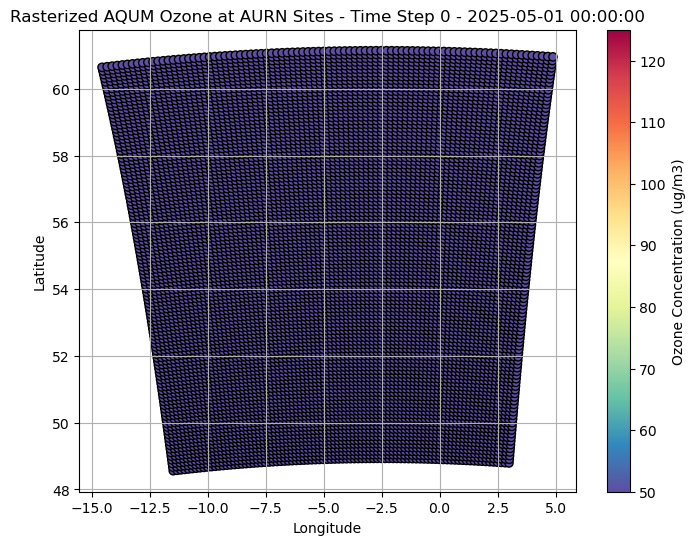

Plotting time step 1 - 2025-05-01 01:00:00


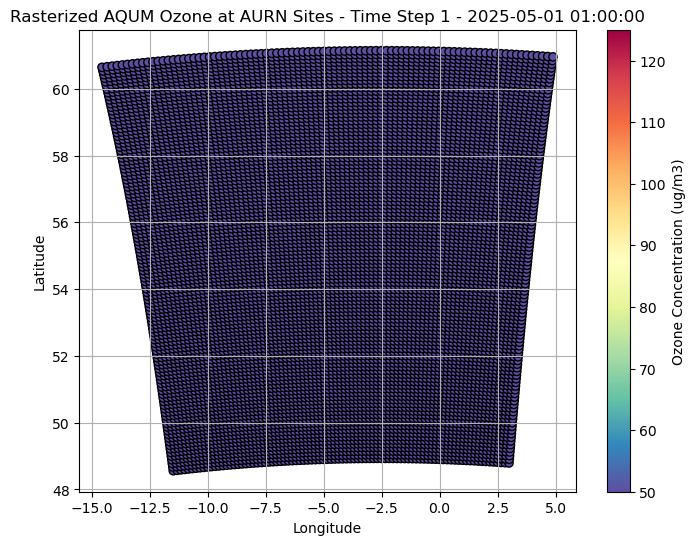

Plotting time step 2 - 2025-05-01 02:00:00


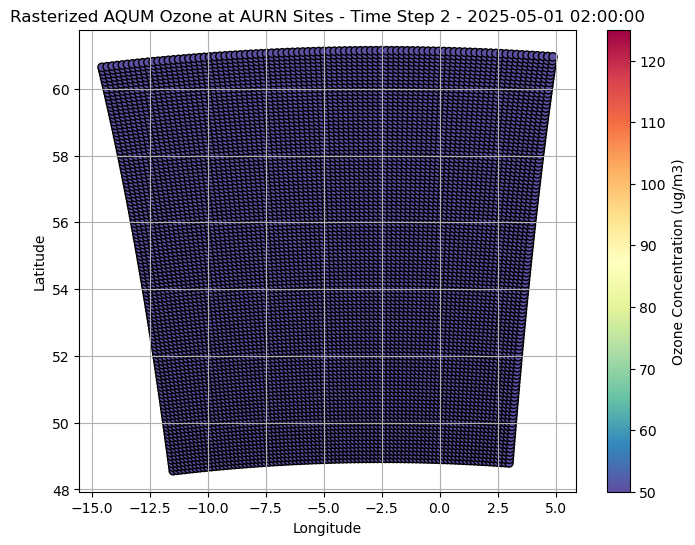

Plotting time step 3 - 2025-05-01 03:00:00


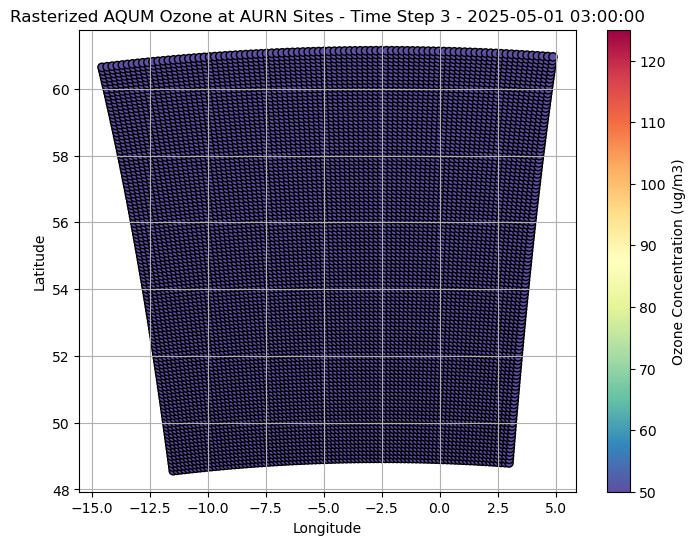

Plotting time step 4 - 2025-05-01 04:00:00


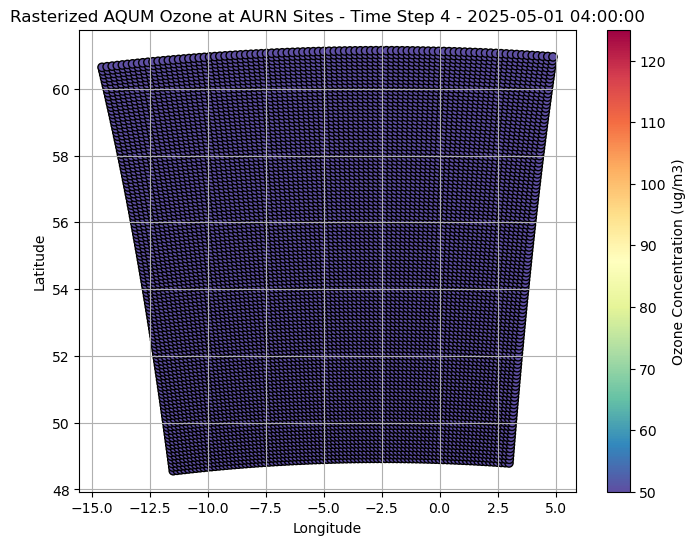

In [4]:
cmap = 'Spectral_r' 

#plot the first five time steps of the rasterized ozone values
for nt in range(ntime):

    # plot first 5 time steps
    if nt >= 5:
        break
    
    print(f"Plotting time step {nt} - {date_str[nt]}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(lon2d_unrotated, lat2d_unrotated, c=rasterized_ozone_at_aurn_site[nt, :, :], edgecolor='black', cmap=cmap, vmin=50, vmax=125)
    plt.colorbar(label='Ozone Concentration (ug/m3)')
    plt.title(f'Rasterized AQUM Ozone at AURN Sites - Time Step {nt} - {date_str[nt]}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid()
    
    #  # UK map window (unrotated lon/lat)
    # uk_lon_min, uk_lon_max = -11.0, 3.0
    # uk_lat_min, uk_lat_max = 48.0, 61.5

    # # Apply UK zoom to the plot
    # plt.xlim(uk_lon_min, uk_lon_max)
    # plt.ylim(uk_lat_min, uk_lat_max)

    # add title with date
    plt.show()